In [35]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special

kpc = const.kpc.cgs.value

atom = ['Lya','HeII','CIV']

def read_file(path_way, atom):
    Mod = pc.CloudyModel(path_way, cloudy_version_major=23)
    Mod.ionic_names

    N_H = sum(Mod.dr*Mod.nH)
    # solar_metallicity
    frac_He =1.00E-01
    frac_C = 2.45E-04
    frac_O = 4.90E-04
    frac_N = 8.51E-05
    frac_Mg = 3.47E-05

    N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
    N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
    N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
    N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
    N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
    N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

    num = len(Mod.nH)
    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[4])
        CIV_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HeII_frac[i] = j
        i = i + 1




    n_H= Mod.nH
    n_He = n_H*frac_He
    n_C = n_H*frac_C
    nden_CIV = CIV_frac*n_C
    nden_HeII = HeII_frac*n_He
    # print('Lya Luminosity = ',float(Mod.get_emis_vol('H__1_121567A')) )
    # print('HeII Luminosity = ',float(Mod.get_emis_vol('HE_2_164043A')) )
    # print('CIV Luminosity = ',float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A')) )

    if atom == 'CIV':
        Cloudy_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        Cloudy_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        Cloudy_den = nden_CIV
    elif atom == 'Lya':
        Cloudy_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Cloudy_emis = Mod.get_emis('H__1_121567A')
        Cloudy_den = n_H
    elif atom == 'HeII':
        Cloudy_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        Cloudy_emis = Mod.get_emis('HE_2_164043A')
        Cloudy_den = nden_HeII
    return Cloudy_Lum , Cloudy_emis ,Cloudy_den

def radius(path, atom):
    Mod = pc.CloudyModel(path, cloudy_version_major=23)
    radius = Mod.radius/kpc
    radius_kpc =Mod.radius 
    dr = Mod.dr 
    return radius, radius_kpc, dr

def make_data_file(path,atom):
    lum ,emis ,den = read_file(path,atom)
    radius_R , radius_kpc , dr=  radius(path,atom)
    tt =  pd.DataFrame(np.column_stack((radius_R,emis,den)))
    tt.to_csv('/home/jin/RT/RT_main/{}_cloudy.txt'.format(atom), sep='\t',index=False,header =False)
    tt.to_csv('/home/jin/RT/RT_scat/{}_cloudy.txt'.format(atom), sep='\t',index = False,header=False)
    return print("make data file!")





def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin

def RT_SB(path):
    name = ['radius','SB_K','SB_H','SB_tot','1','2','3']
    data_sp = pd.read_csv(path, sep='\s+', header=None,names=name)
    rad, SB_t, SB_k,SB_h =  data_sp['radius'].to_numpy(),data_sp['SB_tot'].to_numpy(),data_sp['SB_K'].to_numpy(),data_sp['SB_H'].to_numpy()
    return rad*100, rad*100*kpc, SB_t 

def find_y(x_find,x,y):
    ii = int(np.where(x <= x_find)[0][-1])
    # print(ii)
    y_find = (y[ii+1] -y[ii]) / (x[ii+1] - x[ii])*(x_find - x[ii]) + y[ii]
    return y_find




warnings.filterwarnings("ignore", category=IntegrationWarning)

path_LT = r'/home/jin/RT/RT_main/data_CLOUDY_setting/OTS_n_LT_y/CIV_Lumin_42' # no OTS , yes LT For CIV

RT_path_HeII =r'/home/jin/RT/RT_main/data_HeII_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'
RT_path_CIV = r'/home/jin/RT/RT_main/data_CIV_wo_s/N_atom000E+00_Vexp000E+00_Vemit000E+00_tauD000E+00_Vran000E+00radi.dat'


# make_data_file(path_LT,'CIV')
# make_data_file(path_LT,'HeII')

# ! pip install pyneb


In [36]:

rr = np.arange(13, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

lam_c =  (C_IV_K_A + C_IV_H_A) / 2

voigt_path_11_8 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
voigt_path_30 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
voigt_path_50 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'

NN = int(1e4)


C_IV_N = np.linspace(1e12, 1e17, NN)

def N_esc_scat(line,voigt_path,v_th):


    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)
    lam_0, scat_0 = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam_0-C_IV_K) / C_IV_K) * cc /1e5
    x =   del_V / (v_th/1e5)
    K_H_center = 250  / (v_th/1e5)
    dx = x[1] - x[0]
    x_K = x[np.where(x <= K_H_center)[0]]
    x_H = x[np.where(x >= K_H_center)[0]]
    scat_K = scat_0[np.where(x <= K_H_center)[0]]
    scat_H = scat_0[np.where(x >= K_H_center)[0]]
    x_0 = np.zeros(NN)

    xx_K = 0
    xx_H = 500/ (v_th/1e5)

    if line =='K' or line =='k' :
        x = x_K
        scat = scat_K
        xx_c = xx_K
        ii = np.where( (x > -dx/2) & (x < dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[ii]) ,1/scat[ii]

    elif line == 'H' or line =='h' :
        x = x_H 
        scat = scat_H
        xx_c = xx_H
        jj = np.where( (x > xx_H -dx/2) & (x < xx_H +dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[jj]) ,1/scat[jj]



    tau_profile = np.outer(C_IV_N, scat)
    
    # print(line,'scattering cross-section = ', cross_sec_cen )
    print(line,'Center  Columne density = ', N_CIV_cen  )


    for ii, jj in enumerate(C_IV_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = x[x_p].max() if x_p.size > 0 else 0


    V_del_peak = 2*abs( (x_0 - xx_c)*(v_th/1e5))

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    
    return x ,tau_profile , V_del_peak , N_esc


def calculate_order_and_value(value):

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def data_sp_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy() # total photon
    spec_sc = data[2].to_numpy()  # scattering photon
   # spec_pol_tot = data[3]  # polization of the total photon
   # spec_pol_scat = data[4]  $ polization of the scattering photon
    return lam , spec_tot , spec_sc



#separate K and H line
def data_sp(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  data_sp_com(Line , atom_num , atom_index, vout, vemit, vran)
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = data_sp_com(Line, atom_num, atom_index, vout, vemit, vran)

    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda



def doublet_ratio(Line, atom_num, atom_index, vout, vemit, vran):
    lam_K , spec_tot_K , spec_halo_K = K_H_from_Combine_data('k', atom_num, atom_index, vout, vemit, vran)
    lam_H , spec_tot_H , spec_halo_H = K_H_from_Combine_data('h', atom_num, atom_index, vout, vemit, vran)

    lam_c =  (C_IV_K_A + C_IV_H_A) / 2 

    cut_off_K = np.where(lam_K >= C_IV_K_A + (C_IV_K_A-lam_c))[0]
    cut_off_H = np.where(lam_H <= C_IV_H_A + abs(C_IV_H_A-lam_c))[0]


    cut_spec_tot_K = spec_tot_K[cut_off_K]
    cut_spec_tot_H = spec_tot_H[cut_off_H]

    doublet_line_ratio = np.sum(cut_spec_tot_K) / np.sum(cut_spec_tot_H)

    return doublet_line_ratio


def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel



def tau_0(Line, atom_num, atom_index, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = f_CIV_H

    elif Line == 'k' or Line =='K':
        f_c = f_CIV_K
    T = 1e5
    M = 12
    N_t = (atom_num/10) * 10**(atom_index)
    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (N_t /10**14)
    return tau

In [37]:

def Various_make_parameter(lum,atom):
    path_cloudy = rf'/home/jin/RT/RT_cloudy/L_{lum}/N_H/CIV_Lumin' 
    z_red_Shift = 0
    globals()['{}_radius'.format(atom)] , globals()['{}_radius_kpc'.format(atom)], globals()['dr_{}'.format(atom)] = radius(path_cloudy,atom)
    globals()['{}_lum'.format(atom)] , globals()['{}_emis'.format(atom)] , globals()['{}_den'.format(atom)] = read_file(path_cloudy,atom)
    globals()['{}_p_radius'.format(atom)] , globals()['{}_SB'.format(atom)], globals()['{}_lum_SB'.format(atom)] = SB(z_red_Shift,globals()['{}_radius_kpc'.format(atom)],globals()['{}_emis'.format(atom)]  , globals()['dr_{}'.format(atom)]) # , globals()['rt_radius_kpc_{}'.format(atom)]
    return print("make parameters of {} and L = {}".format(atom , lum))



def Various_RT_make_parameter(z_red_Shift,lum,v_out, v_emit, v_rand, atom):
    # 기본값 설정
    radius_RT, radius_kpc_RT, SB_RT = np.array([0]), np.array([0]), np.array([0])
    radius_CL, sb_CL = np.array([0]), np.array([0])
    normal_RT, normal_CL = 1, 1  # ZeroDivisionError 방지

    if v_out == 0:
        expand, vout_order = "000", 0
    else:
        expand, vout_order = v_out, 2
    # print(v_emit)
    emit, emit_order = calculate_order_and_value(v_emit)    
    # print(emit,emit_order)
    rand, rand_order = calculate_order_and_value(v_rand)
    # print(rand)

    # 파일 경로 설정
    #ubuntu
    path_rt = (f'/home/jin/RT/RT_main/data_cloudy/data_L{lum}/N_atom000E+00_'
                f'Vexp{expand}E+0{vout_order}_Vemit{emit}E+0{emit_order}_'
                f'tauD000E+00_Vran{rand}E+0{rand_order}radi.dat')
    #window
    # path_rt = (f'/home/jin/RT/RT_main/sb_cloudy/data_RT/N_atom000E+00_'
    #             f'Vexp{expand}E+0{vout_order}_Vemit{emit}E+0{emit_order}_'
    #             f'tauD000E+00_Vran{rand}E+0{rand_order}radi.dat')


    # RT_SB 함수 호출
    rt_output = RT_SB(path_rt)
    if rt_output is not None:
        radius_RT, radius_kpc_RT, SB_RT = rt_output

    # SB_RT 값이 None이거나 비어있을 경우 기본값 설정
    if SB_RT is None or len(SB_RT) == 0:
        SB_RT = np.array([0])
    normal_RT = np.sum(SB_RT) if np.sum(SB_RT) != 0 else 1

    print(f"make parameters of v_rand = {v_rand} km/s, v_exp = {v_out} km/s, v_emit = {v_emit} km/s for {atom}")

    # 추가 데이터 처리
    # z_red_Shift = 0
    radius_data = radius(path_LT, atom)
    lum_data = read_file(path_LT, atom)
    sb_data = SB(z_red_Shift, radius_data[1], lum_data[1], radius_data[2])

    if sb_data is not None:
        radius_CL, sb_CL = sb_data[0], sb_data[1]

    # sb_CL 값이 None이거나 비어있을 경우 기본값 설정
    if sb_CL is None or len(sb_CL) == 0:
        sb_CL = np.array([0])
    normal_CL = np.sum(sb_CL) if np.sum(sb_CL) != 0 else 1

    return radius_RT, radius_kpc_RT,  SB_RT/ normal_RT, SB_RT   


def Various_vout_make_parameter(z_red_Shift,lum,v_out, v_emit ,v_rand):
    for ii in v_out:
        nn = int(ii / 100)
        globals()['RT_radius_vout_{}'.format(nn)] , globals()['RT_radius_kpc_vout_{}'.format(nn)], globals()['RT_SB_vout_{}'.format(nn)] , globals()['Or_RT_SB_vout_{}'.format(nn)]= Various_RT_make_parameter(z_red_Shift,lum,ii, v_emit, v_rand,'CIV')[:4]
    return print("Make data!!")


def Various_vemit_make_parameter(z_red_Shift,lum,v_out, v_emit ,v_rand):
    for ii , jj in enumerate (v_emit):
        nn = int(jj / 10)
        globals()['RT_radius_vemit_{}'.format(nn)] , globals()['RT_radius_kpc_vemit_{}'.format(nn)], globals()['RT_SB_vemit_{}'.format(nn)] , globals()['Or_RT_SB_vout_{}'.format(nn)]= Various_RT_make_parameter(z_red_Shift,lum,v_out, jj, v_rand,'CIV')[:4]
    return print("Make data!!")


def Various_vrand_make_parameter(z_red_Shift,lum,v_out, v_emit ,v_rand):
    for ii , jj in enumerate(v_rand):
        nn = int(jj / 10)
        globals()['RT_radius_vrand_{}'.format(nn)] , globals()['RT_radius_kpc_vrand_{}'.format(nn)], globals()['RT_SB_vrand_{}'.format(nn)], globals()['Or_RT_SB_vout_{}'.format(nn)] = Various_RT_make_parameter(z_red_Shift,lum,v_out, v_emit, jj,'CIV')[:4]
    return print("Make data!!")



In [38]:
import math
import math
rr = np.arange(12, 18, 1, dtype=np.float128)

# atom_N을 조건부로 설정
atom_N_list = []
for r_val in rr:
    if r_val == 17:
        atom_N_list.append([10])  # 17일 때는 10만
    else:
        atom_N_list.append([10,13,20,32,50,79])  # 나머지는 전체

# total_N_c 계산
total_N_c = []
for i, r_val in enumerate(rr):
    temp_N_c = np.outer(10**r_val, atom_N_list[i]) / 10
    total_N_c.extend(temp_N_c.flatten())

total_N_c = np.array(total_N_c)

vout = np.arange(0,1100,100)
vemit = 100
vrand = 30
z_red_Shift = 0


ratio = np.zeros((len(vout),len(total_N_c)))

for ii,vv in enumerate(vout):
    # Various_vout_make_parameter(z_red_Shift,lum,vv,vemit,vrand)
    for jj, N_civ in enumerate(total_N_c):
            atom_index = math.floor(math.log10(N_civ))
            atom_num = int(N_civ/ 10**atom_index * 10)
            ratio[ii,jj] = doublet_ratio('all', atom_num, atom_index, vv, vemit, vrand)

            


In [39]:
import numpy as np

# 예: 고정할 column density 값 (실제로 임의의 값 넣음)
atom_num  = 32
index = 15
target_nciv_fixed = (atom_num/10)*10**(index) # 사용자가 원하는 column density 값

# ratio를 numpy array로 가정 (shape: (len(vout), len(total_N_c)))
# vout, total_N_c 도 numpy array로 변환

vout = np.array(vout)
total_N_c = np.array(total_N_c)

# 1) 고정한 column density에 가장 가까운 인덱스 찾기
idx_nciv = np.argmin(np.abs(total_N_c - target_nciv_fixed))

# 2) ratio 행렬에서 해당 column density 열 뽑기
ratio_at_nciv = ratio[:, idx_nciv]  # shape: (len(vout),)

# 3) 입력받은 target ratio 값
target_ratio = 0.8  # 예를 들어

# 4) ratio 와 target_ratio 차이가 최소인 인덱스 (즉, vout 위치) 찾기
idx_vout_closest = np.argmin(np.abs(ratio_at_nciv - target_ratio))

# 5) 그 인덱스에 해당하는 vout, ratio 출력
closest_vout = vout[idx_vout_closest]
closest_ratio = ratio_at_nciv[idx_vout_closest]

print(f"Fixed column density: {total_N_c[idx_nciv]:.2e}")
print(f"Closest ratio to {target_ratio} is {closest_ratio:.3f} at vout = {closest_vout} km/s")


Fixed column density: 3.20e+15
Closest ratio to 0.8 is 0.474 at vout = 1000 km/s


In [40]:
import numpy as np


target_ratio = 0.8
tolerance = 0.05

# ratio는 shape (len(vout), len(total_N_c))
diff = np.abs(ratio - target_ratio)

# tolerance 이내인 모든 위치 인덱스 찾기
indices = np.where(diff <= tolerance)  # tuple: (vout_indices_array, total_N_c_indices_array)

vout_matches = vout[indices[0]]
nciv_matches = total_N_c[indices[1]]
ratio_matches = ratio[indices]

# 결과 개수 출력
print(f"Found {len(ratio_matches)} matches with ratio within ±{tolerance} of {target_ratio}.")

# 상위 몇 개 샘플 출력 (원하는 만큼 조정 가능)
for vi, ni, ri in zip(vout_matches[:10], nciv_matches[:10], ratio_matches[:10]):
    print(f"vout = {vi} km/s, column density = {ni:.2e}, ratio = {ri:.3f}")

Found 5 matches with ratio within ±0.05 of 0.8.
vout = 400 km/s, column density = 2.00e+16, ratio = 0.794
vout = 500 km/s, column density = 1.30e+15, ratio = 0.794
vout = 600 km/s, column density = 1.00e+15, ratio = 0.848
vout = 700 km/s, column density = 1.30e+15, ratio = 0.751
vout = 800 km/s, column density = 1.30e+15, ratio = 0.822


1.9807890820733889
316227766016837.94


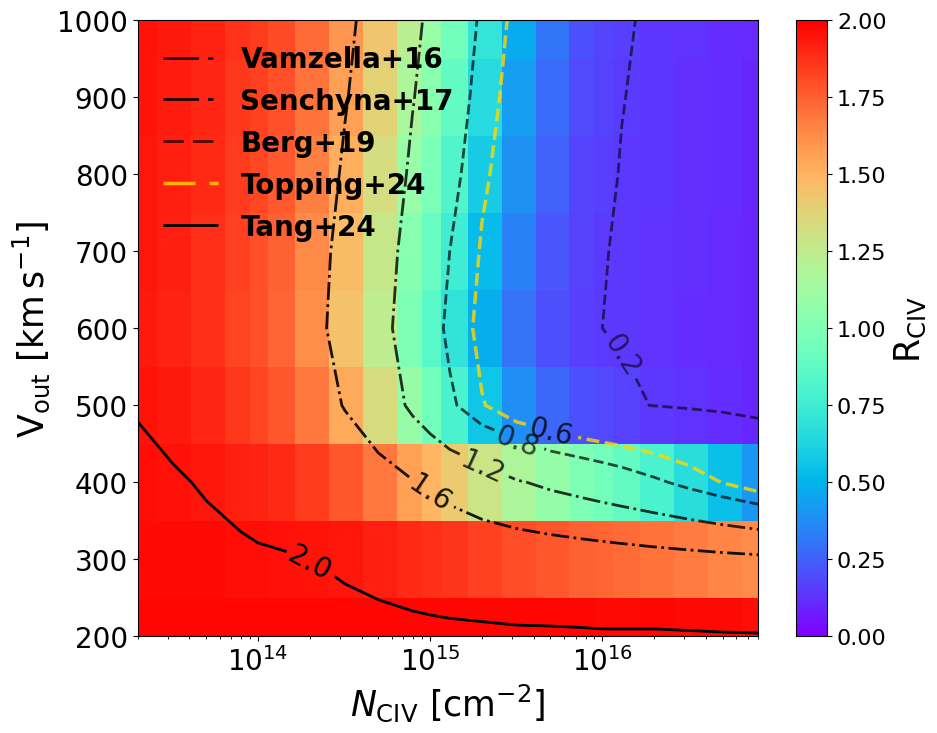

In [41]:
fig = plt.figure(1,figsize=(10,8))

from matplotlib.colors import ListedColormap, BoundaryNorm



x = np.array(total_N_c, dtype=np.float64)
y = np.array(vout, dtype=np.float64)
X, Y = np.meshgrid(x, y)
Z = np.array(ratio, dtype=np.float64)

# 무지개 색상 맵을 적용
# cset = plt.contour(X, Y, Z, cmap='gray',linewidths=2)
cmap = plt.get_cmap('rainbow', 256)  # 숫자를 더 늘릴 수도 있음
plt.pcolormesh(X, Y, Z, shading='auto', cmap='rainbow',vmin=0.0,vmax=2.00) #2.15
cbar = plt.colorbar()

cbar.set_label(r'$\rm R_{\rm CIV}$',fontsize=25)
cbar.ax.tick_params(labelsize=16)  # colorbar 눈금 크기 조정

plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$',fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(2*10**13,8*10**16)
plt.ylim(200,1000)
# levels = [0.79, 1.24, 1.55]
# linestyles = ['solid', 'dashed', 'solid']  # 0.79와 1.55는 solid
# labels = ['Topping+2024', 'Berg+2019', 'Topping+2024']  # 0.79와 1.55는 같은 label

# 0.79, 1.55는 같이 그리고, 1.24는 따로 그림
aa = Z.max()
print(aa)
levels1 = [0.551]
levels2 = [0.751]
levels3 = [1.151]
# levels4 = [1.951]
levels4 = [1.551]
levels5 = [1.951]
levels6 = [0.151]
# levels5 = [0.21,1.0]
# plt.axvline(x=10**(14.5),ymin=0,ymax=1)
print(10**(14.5))


cs6 = plt.contour(X, Y, Z, levels=levels6, colors='k', linewidths=2.0, linestyles='--',alpha=0.6)
plt.clabel(cs6, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')

cs1 = plt.contour(X, Y, Z, levels=levels1, colors='gold', linewidths=2.5, linestyles='--',alpha=0.8)
plt.clabel(cs1, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='black')


cs2 = plt.contour(X, Y, Z, levels=levels2, colors='k', linewidths=2, linestyles='--',alpha=0.7)
plt.clabel(cs2, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5, colors='black')


cs3 = plt.contour(X, Y, Z, levels=levels3, colors='black', linewidths=2, linestyles='dashdot',alpha=0.8)
plt.clabel(cs3, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5)

cs4 = plt.contour(X, Y, Z, levels=levels4, colors='k', linewidths=2, linestyles='dashdot', alpha=0.9)
plt.clabel(cs4, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')

cs5 = plt.contour(X, Y, Z, levels=levels5, colors='k', linewidths=2.0, linestyles='-',alpha=1.0)
plt.clabel(cs5, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')



# legend_elements()로 handle, label 추출
handles1, _ = cs1.legend_elements()
handles2, _ = cs2.legend_elements()
handles3, _ = cs3.legend_elements()
handles4, _ = cs4.legend_elements()
handles5, _ = cs5.legend_elements()


plt.legend(
    [ handles3[0], handles4[0], handles2[0], handles1[0], handles5[0]],
    [ 'Vamzella+16', 'Senchyna+17', 'Berg+19', 'Topping+24','Tang+24'],
    prop={'weight': 'bold', 'size': 20},
    frameon=False,
    loc='upper left'
)

# plt.show()
# plt.savefig(f'/home/jin/바탕화면/2D_plot_V_out_N_CIV_obs_50.pdf',bbox_inches='tight')
# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/2D_plot_V_out_N_CIV_obs_50.pdf',bbox_inches="tight")

In [42]:
from scipy.interpolate import RegularGridInterpolator

# x축: column density, y축: vout
x = np.array(total_N_c, dtype=np.float64)
y = np.array(vout, dtype=np.float64)

interp_func = RegularGridInterpolator((y, x), ratio, bounds_error=False, fill_value=None)

# 새롭게 촘촘한 grid 생성
x_dense = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)
y_dense = np.linspace(y.min(), y.max(), 1000)
X_dense, Y_dense = np.meshgrid(x_dense, y_dense)

points = np.column_stack([Y_dense.ravel(), X_dense.ravel()])
Z_dense = interp_func(points).reshape(Y_dense.shape)

In [73]:
atom_num  = 32.0
index = 15
target_nciv_fixed = (atom_num/10)*10**(index) # 사용자가 원하는 column density 값

# ratio를 numpy array로 가정 (shape: (len(vout), len(total_N_c)))
# vout, total_N_c 도 numpy array로 변환


# 1) 고정한 column density에 가장 가까운 인덱스 찾기
idx_nciv = np.argmin(np.abs(x_dense - target_nciv_fixed))

# 2) ratio 행렬에서 해당 column density 열 뽑기
ratio_at_nciv = Z_dense[:, idx_nciv]  # shape: (len(vout),)

# 3) 입력받은 target ratio 값
target_ratio = 1.0 # 예를 들어

# 4) ratio 와 target_ratio 차이가 최소인 인덱스 (즉, vout 위치) 찾기
idx_vout_closest = np.argmin(np.abs(ratio_at_nciv - target_ratio))

# 5) 그 인덱스에 해당하는 vout, ratio 출력
closest_vout = y_dense[idx_vout_closest]
closest_ratio = ratio_at_nciv[idx_vout_closest]

print(f"Fixed column density: {x_dense[idx_nciv]:.2e}")
print(f"Closest ratio to {target_ratio} is {closest_ratio:.3f} at vout = {closest_vout:.0f} km/s")

Fixed column density: 3.19e+15
Closest ratio to 1.0 is 0.997 at vout = 422 km/s


In [ ]:
# atom_num  = 79.0
# index = 14
# target_nciv_fixed = (atom_num/10)*10**(index) # 사용자가 원하는 column density 값

# # ratio를 numpy array로 가정 (shape: (len(vout), len(total_N_c)))
# # vout, total_N_c 도 numpy array로 변환


# # 1) 고정한 column density에 가장 가까운 인덱스 찾기
# idx_nciv = np.argmin(np.abs(x_dense - target_nciv_fixed))

# # 2) ratio 행렬에서 해당 column density 열 뽑기
# ratio_at_nciv = Z_dense[:, idx_nciv]  # shape: (len(vout),)

# # 3) 입력받은 target ratio 값
# target_ratio = 1.0 # 예를 들어

# # 4) ratio 와 target_ratio 차이가 최소인 인덱스 (즉, vout 위치) 찾기
# idx_vout_closest = np.argmin(np.abs(ratio_at_nciv - target_ratio))

# # 5) 그 인덱스에 해당하는 vout, ratio 출력
# closest_vout = y_dense[idx_vout_closest]
# closest_ratio = ratio_at_nciv[idx_vout_closest]

# print(f"Fixed column density: {x_dense[idx_nciv]:.2e}")
# print(f"Closest ratio to {target_ratio} is {closest_ratio:.3f} at vout = {closest_vout:.0f} km/s")

In [60]:
from scipy.interpolate import interp1d

target_vout = 600
idx_vout = np.argmin(np.abs(y_dense - target_vout))
ratios_at_vout = Z_dense[idx_vout, :]    # 이 vout에서의 ratio vs N_CIV

# 단조 증가 또는 감소가 아닐 수 있으므로, 가장 가까운 값 찾기 방법 예시:
target_ratio = 1.0
idx_closest = np.argmin(np.abs(ratios_at_vout - target_ratio))
Nc_at_target = x_dense[idx_closest]

print(f"vout={target_vout}km/s에서 ratio={target_ratio}일 때 column density ≈ {Nc_at_target: .2e}")

vout=600km/s에서 ratio=1.0일 때 column density ≈  7.72e+14


In [65]:
def _choose_label_points_in_yband(cs, ylo=500, yhi=600, min_dx_frac=0.10, prefer_x="middle"):
    """
    cs: contour set
    ylo~yhi: 라벨을 놓고 싶은 y 범위
    min_dx_frac: x범위 대비 라벨들 최소 간격(겹침 방지용)
    prefer_x: "left" | "middle" | "right"  (밴드 내 후보 중 어느 x를 선호할지)
    반환: manual points list (각 level당 1개 정도)
    """
    # 축 범위 기반으로 최소 dx 설정 (log 축이어도 여기선 데이터 좌표 기준)
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    # log축이면 x0<x1이지만 값 차가 클 수 있으니 log에서 간격을 잡아도 됨
    # 여기서는 log 고려해 "log10 간격"으로 거리 판단
    logx0, logx1 = np.log10(min(x0, x1)), np.log10(max(x0, x1))
    min_dlogx = abs(logx1 - logx0) * min_dx_frac

    chosen = []
    chosen_logx = []

    for col in cs.collections:
        best = None  # (score, x, y)
        for p in col.get_paths():
            v = p.vertices  # (N,2)
            if v.size == 0:
                continue
            mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
            if not np.any(mask):
                continue

            vv = v[mask]
            # 후보 중에서 x 선호 기준으로 한 점 고르기
            if prefer_x == "left":
                cand = vv[np.argmin(vv[:, 0])]
            elif prefer_x == "right":
                cand = vv[np.argmax(vv[:, 0])]
            else:  # "middle"
                xmid = np.nanmedian(vv[:, 0])
                cand = vv[np.argmin(np.abs(vv[:, 0] - xmid))]

            x, y = float(cand[0]), float(cand[1])

            # 점수: y-band 중앙에 가까울수록 좋게
            ymid = 0.5 * (ylo + yhi)
            score = abs(y - ymid)

            if (best is None) or (score < best[0]):
                best = (score, x, y)

        if best is None:
            # 이 level은 yband를 안 지나감 -> 나중에 fallback으로 처리
            chosen.append(None)
            continue

        _, x, y = best
        lx = np.log10(x)

        # 이미 선택된 라벨들과 x(log) 간격이 너무 가까우면,
        # 약간 다른 후보를 찾는 간단한 재시도(좌/우로)
        if any(abs(lx - lxi) < min_dlogx for lxi in chosen_logx):
            # 대안: prefer_x를 left/right로 바꿔서 한번 더 시도
            alt_prefer = "left" if prefer_x != "left" else "right"
            best2 = None
            for p in col.get_paths():
                v = p.vertices
                mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
                if not np.any(mask):
                    continue
                vv = v[mask]
                if alt_prefer == "left":
                    cand = vv[np.argmin(vv[:, 0])]
                else:
                    cand = vv[np.argmax(vv[:, 0])]
                x2, y2 = float(cand[0]), float(cand[1])
                lx2 = np.log10(x2)
                if any(abs(lx2 - lxi) < min_dlogx for lxi in chosen_logx):
                    continue
                score2 = abs(y2 - 0.5 * (ylo + yhi))
                if (best2 is None) or (score2 < best2[0]):
                    best2 = (score2, x2, y2)

            if best2 is not None:
                _, x, y = best2
                lx = np.log10(x)
            # 그래도 안되면 그냥 원래 best 사용

        chosen.append((x, y))
        chosen_logx.append(lx)

    return chosen

# rotation_mode="anchor"
def clabel_in_yband(cs, ylo=500, yhi=600, *, fmt="%1.1f",
                    fontsize=15, inline=True, inline_spacing=5,
                    rightside_up=True,
                    min_dx_frac=0.10, prefer_x="middle",
                    fallback=True, fallback_n=1):
    """
    contour 라벨을 y-band에 자동 배치하고(곡선 방향 자동 회전),
    너무 붙으면 x간격 기준으로 최대한 떨어뜨리며,
    y-band를 안 지나는 레벨은 fallback으로 기본 clabel을 조금만 찍음.
    """
    manual_pts = _choose_label_points_in_yband(
        cs, ylo=ylo, yhi=yhi, min_dx_frac=min_dx_frac, prefer_x=prefer_x
    )

    # yband 지나가는 것들만 모아서 1차 라벨
    manual_good = [pt for pt in manual_pts if pt is not None]

    texts = []
    if len(manual_good) > 0:
        texts = plt.clabel(
            cs, manual=manual_good,
            inline=inline, fontsize=fontsize, fmt=fmt,
            inline_spacing=inline_spacing,
            rightside_up=rightside_up
        )
        # for t in texts:
            # t.set_rotation_mode(rotation_mode)

    # fallback: yband 안 지나는 레벨도 라벨이 필요하면 기본 clabel을 조금만
    if fallback:
        # 이미 찍힌 라벨이 너무 많아지는 걸 막기 위해 fallback_n만큼만
        # (levels이 1개짜리면 사실상 1개만)
        if len(manual_good) < fallback_n:
            texts2 = plt.clabel(
                cs, inline=inline, fontsize=fontsize, fmt=fmt,
                inline_spacing=inline_spacing,
                rightside_up=rightside_up
            )
            # 중복 라벨이 생길 수 있으니, 이미 찍힌 텍스트와 너무 가까우면 숨김
            # (간단히 bbox overlap은 생략하고, 개수만 제한)
            if len(texts2) > fallback_n:
                for t in texts2[fallback_n:]:
                    t.set_visible(False)
            # for t in texts2:
                # t.set_rotation_mode(rotation_mode)

    return cs



316227766016837.94


/tmp/ipykernel_1637/3318989686.py:20: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for col in cs.collections:


(190.0, 1000.0)

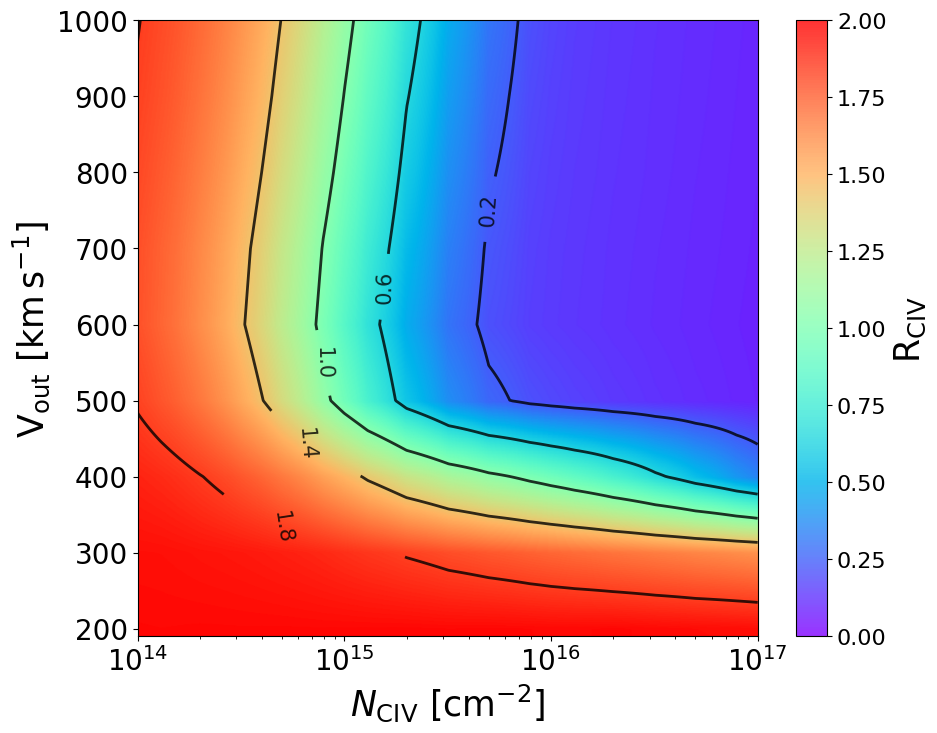

In [66]:
import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(10,8))

cmap = plt.get_cmap('rainbow', 256)  # 숫자를 더 늘릴 수도 있음
# plt.pcolormesh(X, Y, Z, shading='auto', cmap='rainbow',vmin=0.0,vmax=2.00) #2.15
# cbar = plt.colorbar()

plt.pcolormesh(X_dense, Y_dense, Z_dense, shading='gouraud', cmap='rainbow', vmin=0.0, vmax=2.0, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label(r'$\rm R_{\rm CIV}$', fontsize=25)
cbar.ax.tick_params(labelsize=16)

# levels1 = [0.55]
# levels2 = [0.70/]
levels2 = [0.241]
levels3 = [0.641]
levels4 = [1.041]
levels5 = [1.441]
levels6 = [1.841]
# levels5 = [0.21,1.0]
# plt.axvline(x=10**(14.5),ymin=0,ymax=1)
print(10**(14.5))



# cs1 = plt.contour(X, Y, Z, levels=levels1, colors='k', linewidths=2, linestyles='--',alpha=0.6)
# plt.clabel(cs1, inline=True, fontsize=20, fmt='%1.2f', inline_spacing=5,colors='black')


cs2 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels2, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs2, ylo=700, yhi=800, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)



cs3 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels3, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs3, ylo=600, yhi=700, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)


cs4 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels4, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs4, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)

cs5 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels5, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs5, ylo=400, yhi=500, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)

cs6 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels6, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs6, ylo=300, yhi=400, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)




# handles1, _ = cs1.legend_elements()
# handles2, _ = cs2.legend_elements() # Topping+24
# handles3, _ = cs3.legend_elements() # Berg+19
# handles4, _ = cs4.legend_elements() # Topping+24
# handles6, _ = cs6.legend_elements() # Vamzella+16

# plt.legend(
#     [ handles6[0], handles3[0], handles4[0]],
#     [ 'Vamzella+16','Berg+19','Topping+24'],
#     prop={'weight': 'bold', 'size': 20},
#     frameon=False,
#     loc='upper right'
# )
# from matplotlib.lines import Line2D
# legend_elements = [
#     # Line2D([0], [0], color='k', lw=3.0, linestyle='-', label='Vamzella+16'),
#     # Line2D([0], [0], color='black', lw=2.5, linestyle='dashdot', label='Berg+19'),
#     # Line2D([0], [0], color='k', lw=3, linestyle='--', label='Topping+24')
#     Line2D([0], [0], color='k', lw=3.0, linestyle='-'),
#     Line2D([0], [0], color='black', lw=2.5, linestyle='dashdot', label='Berg+19'),
#     Line2D([0], [0], color='k', lw=3, linestyle='--', label='Topping+24')
# ]

# plt.legend(handles=legend_elements,
#            prop={'weight': 'bold', 'size': 20},
#            frameon=False,
#            loc='upper right')

plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$', fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(1e14, 1e17)
plt.ylim(190, 1000)
# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/2D_plot_V_out_N_CIV_obs_30',bbox_inches="tight")

In [67]:
import numpy as np
import matplotlib.pyplot as plt


def _choose_label_points_in_yband(cs, ylo=500, yhi=600, min_dx_frac=0.10, prefer_x="middle"):
    """
    cs: contour set
    ylo~yhi: 라벨을 놓고 싶은 y 범위
    min_dx_frac: x범위 대비 라벨들 최소 간격(겹침 방지용, log10 기준)
    prefer_x: "left" | "middle" | "right"
    반환: manual points list (각 level당 1개 정도)
    """
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    logx0, logx1 = np.log10(min(x0, x1)), np.log10(max(x0, x1))
    min_dlogx = abs(logx1 - logx0) * min_dx_frac

    chosen = []
    chosen_logx = []

    for col in cs.collections:
        best = None  # (score, x, y)

        for p in col.get_paths():
            v = p.vertices
            if v.size == 0:
                continue

            mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
            if not np.any(mask):
                continue

            vv = v[mask]

            if prefer_x == "left":
                cand = vv[np.argmin(vv[:, 0])]
            elif prefer_x == "right":
                cand = vv[np.argmax(vv[:, 0])]
            else:
                xmid = np.nanmedian(vv[:, 0])
                cand = vv[np.argmin(np.abs(vv[:, 0] - xmid))]

            x, y = float(cand[0]), float(cand[1])

            ymid = 0.5 * (ylo + yhi)
            score = abs(y - ymid)

            if (best is None) or (score < best[0]):
                best = (score, x, y)

        if best is None:
            chosen.append(None)
            continue

        _, x, y = best
        lx = np.log10(x)

        if any(abs(lx - lxi) < min_dlogx for lxi in chosen_logx):
            alt_prefer = "left" if prefer_x != "left" else "right"
            best2 = None

            for p in col.get_paths():
                v = p.vertices
                mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
                if not np.any(mask):
                    continue
                vv = v[mask]

                if alt_prefer == "left":
                    cand = vv[np.argmin(vv[:, 0])]
                else:
                    cand = vv[np.argmax(vv[:, 0])]

                x2, y2 = float(cand[0]), float(cand[1])
                lx2 = np.log10(x2)

                if any(abs(lx2 - lxi) < min_dlogx for lxi in chosen_logx):
                    continue

                score2 = abs(y2 - 0.5 * (ylo + yhi))
                if (best2 is None) or (score2 < best2[0]):
                    best2 = (score2, x2, y2)

            if best2 is not None:
                _, x, y = best2
                lx = np.log10(x)

        chosen.append((x, y))
        chosen_logx.append(lx)

    return chosen


def clabel_in_yband_fixed_angle(
    cs, ylo=500, yhi=600, *,
    fmt="%1.1f",
    fontsize=15,
    inline=True,
    inline_spacing=5,
    rotation_mode="anchor",
    min_dx_frac=0.10,
    prefer_x="middle",
    fallback=True,
    fallback_n=1,
    angle_deg=25,          # ★ 여기 각도를 고정 (도 단위)
    force_upright=True     # ★ 글자 upside-down 방지(원하면 False)
):
    """
    contour 라벨을 y-band에 자동 배치하되,
    라벨 회전은 angle_deg로 "고정"한다.
    """
    manual_pts = _choose_label_points_in_yband(
        cs, ylo=ylo, yhi=yhi, min_dx_frac=min_dx_frac, prefer_x=prefer_x
    )
    manual_good = [pt for pt in manual_pts if pt is not None]

    texts_all = []

    # 1) yband 지나는 레벨들: manual로 라벨 찍기
    if len(manual_good) > 0:
        texts = plt.clabel(
            cs, manual=manual_good,
            inline=inline, fontsize=fontsize, fmt=fmt,
            inline_spacing=inline_spacing,
            rightside_up=False  # ★ 자동 뒤집기 끄고 우리가 통제
        )
        texts_all.extend(texts)

    # 2) fallback: yband 안 지나는 레벨도 라벨이 필요하면 조금만 찍기
    if fallback:
        if len(manual_good) < fallback_n:
            texts2 = plt.clabel(
                cs, inline=inline, fontsize=fontsize, fmt=fmt,
                inline_spacing=inline_spacing,
                rightside_up=False
            )
            if len(texts2) > fallback_n:
                for t in texts2[fallback_n:]:
                    t.set_visible(False)
            texts_all.extend(texts2[:fallback_n])

    # 3) 회전 "강제 고정"
    #    force_upright=True면 180도 뒤집힌 형태를 방지하려고 angle을 [0,180) 범위로 정리
    ang = float(angle_deg)
    if force_upright:
        ang = ang % 360
        if 90 < ang < 270:
            ang = (ang + 180) % 360  # 필요 시 뒤집어서 글자가 거꾸로 안 보이게

    for t in texts_all:
        t.set_rotation_mode(rotation_mode)
        t.set_rotation(ang)

    return cs


316227766016837.94


/tmp/ipykernel_1637/2278669167.py:21: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for col in cs.collections:


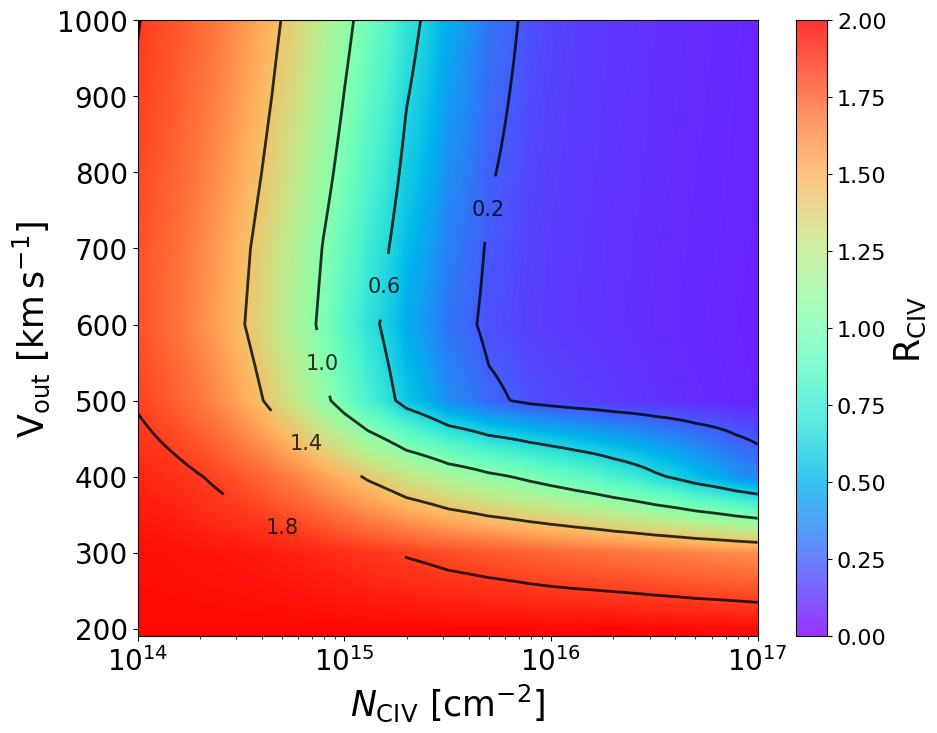

In [70]:
import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(10,8))

cmap = plt.get_cmap('rainbow', 256)  # 숫자를 더 늘릴 수도 있음
# plt.pcolormesh(X, Y, Z, shading='auto', cmap='rainbow',vmin=0.0,vmax=2.00) #2.15
# cbar = plt.colorbar()

plt.pcolormesh(X_dense, Y_dense, Z_dense, shading='gouraud', cmap='rainbow', vmin=0.0, vmax=2.0, alpha=0.8)
cbar = plt.colorbar()
cbar.set_label(r'$\rm R_{\rm CIV}$', fontsize=25)
cbar.ax.tick_params(labelsize=16)

# levels1 = [0.55]
# levels2 = [0.70/]
levels2 = [0.241]
levels3 = [0.641]
levels4 = [1.041]
levels5 = [1.441]
levels6 = [1.841]
# levels5 = [0.21,1.0]
# plt.axvline(x=10**(14.5),ymin=0,ymax=1)
print(10**(14.5))



# cs1 = plt.contour(X, Y, Z, levels=levels1, colors='k', linewidths=2, linestyles='--',alpha=0.6)
# plt.clabel(cs1, inline=True, fontsize=20, fmt='%1.2f', inline_spacing=5,colors='black')

angle= 0

cs2 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels2, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband_fixed_angle(cs2, ylo=700, yhi=800, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10,
                            angle_deg=angle)

cs3 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels3, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband_fixed_angle(cs3, ylo=600, yhi=700, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10,
                            angle_deg=angle)

cs4 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels4, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband_fixed_angle(cs4, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10,
                            angle_deg=angle)

cs5 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels5, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband_fixed_angle(cs5, ylo=400, yhi=500, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10,
                            angle_deg=angle)

cs6 = plt.contour(X_dense, Y_dense, Z_dense, levels=levels6, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband_fixed_angle(cs6, ylo=300, yhi=400, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10,
                            angle_deg=angle)



# handles1, _ = cs1.legend_elements()
# handles2, _ = cs2.legend_elements() # Topping+24
# handles3, _ = cs3.legend_elements() # Berg+19
# handles4, _ = cs4.legend_elements() # Topping+24
# handles6, _ = cs6.legend_elements() # Vamzella+16

# plt.legend(
#     [ handles6[0], handles3[0], handles4[0]],
#     [ 'Vamzella+16','Berg+19','Topping+24'],
#     prop={'weight': 'bold', 'size': 20},
#     frameon=False,
#     loc='upper right'
# )
# from matplotlib.lines import Line2D
# legend_elements = [
#     # Line2D([0], [0], color='k', lw=3.0, linestyle='-', label='Vamzella+16'),
#     # Line2D([0], [0], color='black', lw=2.5, linestyle='dashdot', label='Berg+19'),
#     # Line2D([0], [0], color='k', lw=3, linestyle='--', label='Topping+24')
#     Line2D([0], [0], color='k', lw=3.0, linestyle='-'),
#     Line2D([0], [0], color='black', lw=2.5, linestyle='dashdot', label='Berg+19'),
#     Line2D([0], [0], color='k', lw=3, linestyle='--', label='Topping+24')
# ]

# plt.legend(handles=legend_elements,
#            prop={'weight': 'bold', 'size': 20},
#            frameon=False,
#            loc='upper right')

plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$', fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(1e14, 1e17)
plt.ylim(190, 1000)
# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/2D_plot_V_out_N_CIV_obs_30',bbox_inches="tight")

/tmp/ipykernel_1637/2149704820.py:65: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for col in cs.collections:


(200.0, 1000.0)

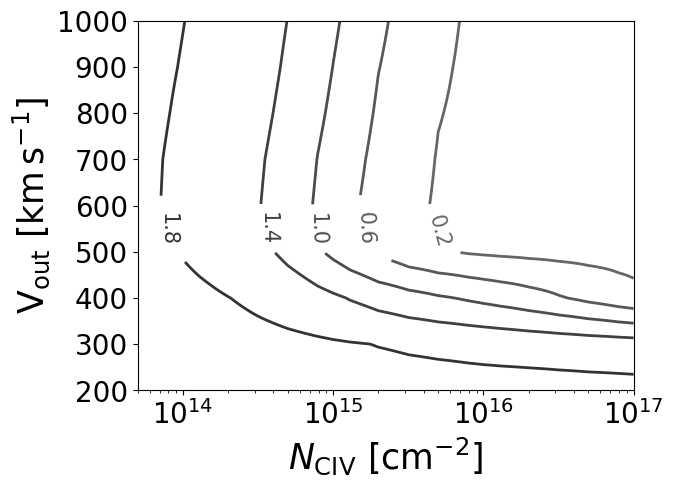

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) (선택) 2D grid 보간해서 contour를 매끈하게 만들기
# =========================================================
def make_interpolated_grid(X, Y, Z, nx=500, ny=500, method="cubic"):
    """
    X, Y, Z: 2D meshgrid 또는 1D/2D 형태 모두 가능
    nx, ny: 새 그리드 해상도
    method: "linear", "cubic", "nearest" (scipy griddata 방식)

    반환: Xi, Yi, Zi (meshgrid + 보간된 Z)
    """
    try:
        from scipy.interpolate import griddata
    except ImportError as e:
        raise ImportError("scipy가 필요합니다: pip install scipy") from e

    X = np.asarray(X)
    Y = np.asarray(Y)
    Z = np.asarray(Z)

    # (N,) 포인트로 flatten
    pts = np.column_stack([X.ravel(), Y.ravel()])
    vals = Z.ravel()

    # 새 그리드
    xi = np.linspace(np.nanmin(X), np.nanmax(X), nx)
    yi = np.linspace(np.nanmin(Y), np.nanmax(Y), ny)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata(pts, vals, (Xi, Yi), method=method)

    # cubic/linear은 바깥 영역 NaN 나올 수 있어 -> nearest로 한번 메꿈(선택적)
    if np.isnan(Zi).any():
        Zi2 = griddata(pts, vals, (Xi, Yi), method="nearest")
        Zi = np.where(np.isnan(Zi), Zi2, Zi)

    return Xi, Yi, Zi


# =========================================================
# 2) 라벨을 y-band에서 자동 선택 + 겹침 최소화 + fallback
# =========================================================
def _choose_label_points_in_yband(cs, ylo=500, yhi=600, min_dx_frac=0.10, prefer_x="middle"):
    """
    cs: contour set
    ylo~yhi: 라벨을 놓고 싶은 y 범위
    min_dx_frac: x범위 대비 라벨들 최소 간격(겹침 방지용)
    prefer_x: "left" | "middle" | "right"  (밴드 내 후보 중 어느 x를 선호할지)
    반환: manual points list (각 level당 1개 정도)
    """
    # 축 범위 기반으로 최소 dx 설정 (log 축이어도 여기선 데이터 좌표 기준)
    ax = plt.gca()
    x0, x1 = ax.get_xlim()
    # log축이면 x0<x1이지만 값 차가 클 수 있으니 log에서 간격을 잡아도 됨
    # 여기서는 log 고려해 "log10 간격"으로 거리 판단
    logx0, logx1 = np.log10(min(x0, x1)), np.log10(max(x0, x1))
    min_dlogx = abs(logx1 - logx0) * min_dx_frac

    chosen = []
    chosen_logx = []

    for col in cs.collections:
        best = None  # (score, x, y)
        for p in col.get_paths():
            v = p.vertices  # (N,2)
            if v.size == 0:
                continue
            mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
            if not np.any(mask):
                continue

            vv = v[mask]
            # 후보 중에서 x 선호 기준으로 한 점 고르기
            if prefer_x == "left":
                cand = vv[np.argmin(vv[:, 0])]
            elif prefer_x == "right":
                cand = vv[np.argmax(vv[:, 0])]
            else:  # "middle"
                xmid = np.nanmedian(vv[:, 0])
                cand = vv[np.argmin(np.abs(vv[:, 0] - xmid))]

            x, y = float(cand[0]), float(cand[1])

            # 점수: y-band 중앙에 가까울수록 좋게
            ymid = 0.5 * (ylo + yhi)
            score = abs(y - ymid)

            if (best is None) or (score < best[0]):
                best = (score, x, y)

        if best is None:
            # 이 level은 yband를 안 지나감 -> 나중에 fallback으로 처리
            chosen.append(None)
            continue

        _, x, y = best
        lx = np.log10(x)

        # 이미 선택된 라벨들과 x(log) 간격이 너무 가까우면,
        # 약간 다른 후보를 찾는 간단한 재시도(좌/우로)
        if any(abs(lx - lxi) < min_dlogx for lxi in chosen_logx):
            # 대안: prefer_x를 left/right로 바꿔서 한번 더 시도
            alt_prefer = "left" if prefer_x != "left" else "right"
            best2 = None
            for p in col.get_paths():
                v = p.vertices
                mask = (v[:, 1] >= ylo) & (v[:, 1] <= yhi)
                if not np.any(mask):
                    continue
                vv = v[mask]
                if alt_prefer == "left":
                    cand = vv[np.argmin(vv[:, 0])]
                else:
                    cand = vv[np.argmax(vv[:, 0])]
                x2, y2 = float(cand[0]), float(cand[1])
                lx2 = np.log10(x2)
                if any(abs(lx2 - lxi) < min_dlogx for lxi in chosen_logx):
                    continue
                score2 = abs(y2 - 0.5 * (ylo + yhi))
                if (best2 is None) or (score2 < best2[0]):
                    best2 = (score2, x2, y2)

            if best2 is not None:
                _, x, y = best2
                lx = np.log10(x)
            # 그래도 안되면 그냥 원래 best 사용

        chosen.append((x, y))
        chosen_logx.append(lx)

    return chosen


def clabel_in_yband(cs, ylo=500, yhi=600, *, fmt="%1.1f",
                    fontsize=15, inline=True, inline_spacing=5,
                    rightside_up=True, rotation_mode="anchor",
                    min_dx_frac=0.10, prefer_x="middle",
                    fallback=True, fallback_n=1):
    """
    contour 라벨을 y-band에 자동 배치하고(곡선 방향 자동 회전),
    너무 붙으면 x간격 기준으로 최대한 떨어뜨리며,
    y-band를 안 지나는 레벨은 fallback으로 기본 clabel을 조금만 찍음.
    """
    manual_pts = _choose_label_points_in_yband(
        cs, ylo=ylo, yhi=yhi, min_dx_frac=min_dx_frac, prefer_x=prefer_x
    )

    # yband 지나가는 것들만 모아서 1차 라벨
    manual_good = [pt for pt in manual_pts if pt is not None]

    texts = []
    if len(manual_good) > 0:
        texts = plt.clabel(
            cs, manual=manual_good,
            inline=inline, fontsize=fontsize, fmt=fmt,
            inline_spacing=inline_spacing,
            rightside_up=rightside_up
        )
        for t in texts:
            t.set_rotation_mode(rotation_mode)

    # fallback: yband 안 지나는 레벨도 라벨이 필요하면 기본 clabel을 조금만
    if fallback:
        # 이미 찍힌 라벨이 너무 많아지는 걸 막기 위해 fallback_n만큼만
        # (levels이 1개짜리면 사실상 1개만)
        if len(manual_good) < fallback_n:
            texts2 = plt.clabel(
                cs, inline=inline, fontsize=fontsize, fmt=fmt,
                inline_spacing=inline_spacing,
                rightside_up=rightside_up
            )
            # 중복 라벨이 생길 수 있으니, 이미 찍힌 텍스트와 너무 가까우면 숨김
            # (간단히 bbox overlap은 생략하고, 개수만 제한)
            if len(texts2) > fallback_n:
                for t in texts2[fallback_n:]:
                    t.set_visible(False)
            for t in texts2:
                t.set_rotation_mode(rotation_mode)

    return cs


# =========================================================
# 3) 네 contour 구간에 바로 적용하는 예시
# =========================================================
# levels2..levels6는 네가 쓰던 그대로
# levels2 = [0.4]
# levels3 = [0.8]
# levels4 = [1.2]
# levels5 = [1.6]
# levels6 = [1.8]

# --- (옵션) 만약 X_dense,Y_dense,Z_dense가 이미 충분히 매끈하면 보간 스킵해도 됨 ---
# (보간 하고 싶으면 아래처럼)
# Xi, Yi, Zi = make_interpolated_grid(X_dense, Y_dense, Z_dense, nx=700, ny=700, method="cubic")
# Xp, Yp, Zp = Xi, Yi, Zi
# (보간 없이 그대로)
Xp, Yp, Zp = X_dense, Y_dense, Z_dense

# contour들
cs2 = plt.contour(Xp, Yp, Zp, levels=levels2, colors='k', linewidths=2, linestyles='-', alpha=0.6)
clabel_in_yband(cs2, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=5, min_dx_frac=0.10)

cs3 = plt.contour(Xp, Yp, Zp, levels=levels3, colors='k', linewidths=2, linestyles='-', alpha=0.65)
clabel_in_yband(cs3, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)

cs4 = plt.contour(Xp, Yp, Zp, levels=levels4, colors='k', linewidths=2, linestyles='-', alpha=0.7)
clabel_in_yband(cs4, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=3, min_dx_frac=0.10)

cs5 = plt.contour(Xp, Yp, Zp, levels=levels5, colors='k', linewidths=2, linestyles='-', alpha=0.75)
clabel_in_yband(cs5, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=3, min_dx_frac=0.10)

cs6 = plt.contour(Xp, Yp, Zp, levels=levels6, colors='k', linewidths=2, linestyles='-', alpha=0.8)
clabel_in_yband(cs6, ylo=500, yhi=600, fmt="%1.1f", fontsize=15, inline_spacing=10, min_dx_frac=0.10)


plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$', fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(5e13, 1e17)
plt.ylim(200, 1000)


In [48]:
# from scipy.interpolate import RegularGridInterpolator


# x = total_N_c             # x축: column density (len(total_N_c))
# y = vout                  # y축: outflow velocity (len(vout))
# interp_func = RegularGridInterpolator((y, x), ratio)

# # 3) 원하는 (vout_query, N_civ_query) 값에 대해 ratio 예측 가능
# vout_query = 450
# N_civ_query = 5e15
# ratio_smooth = interp_func([vout_query, N_civ_query])

(200.0, 1000.0)

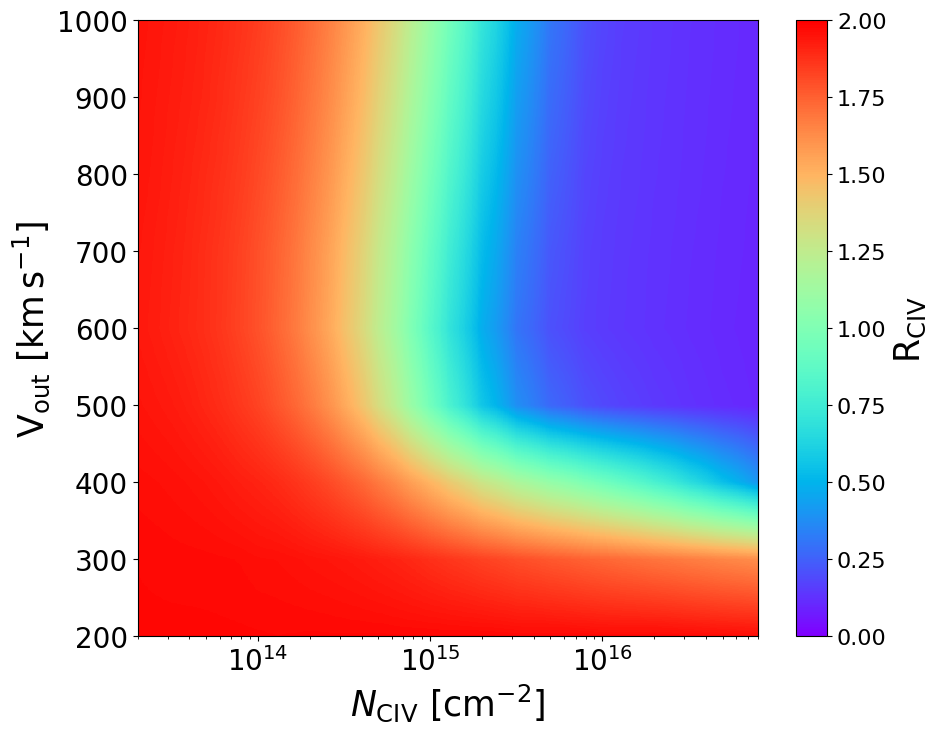

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(10,8))
plt.pcolormesh(X_dense, Y_dense, Z_dense, shading='auto', cmap='rainbow', vmin=0.0, vmax=2.0)
cbar = plt.colorbar()
cbar.set_label(r'$\rm R_{\rm CIV}$', fontsize=25)
cbar.ax.tick_params(labelsize=16)

plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$', fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(2e13, 8e16)
plt.ylim(200, 1000)

In [50]:
idx = np.argmin(ratio)
ii, jj = np.unravel_index(idx, ratio.shape)
print(ii, jj)

6 30


1.9807890820733889
316227766016837.94


<a list of 1 text.Text objects>

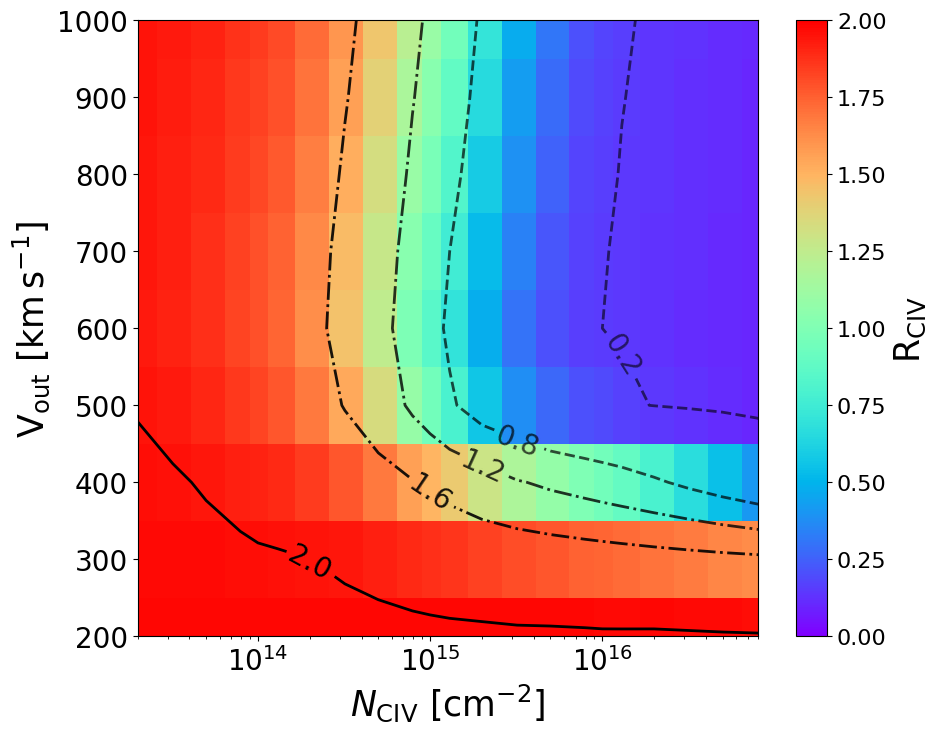

In [51]:
fig = plt.figure(1,figsize=(10,8))

from matplotlib.colors import ListedColormap, BoundaryNorm



x = np.array(total_N_c, dtype=np.float64)
y = np.array(vout, dtype=np.float64)
X, Y = np.meshgrid(x, y)
Z = np.array(ratio, dtype=np.float64)

# 무지개 색상 맵을 적용
# cset = plt.contour(X, Y, Z, cmap='gray',linewidths=2)
cmap = plt.get_cmap('rainbow', 256)  # 숫자를 더 늘릴 수도 있음
plt.pcolormesh(X, Y, Z, shading='auto', cmap='rainbow',vmin=0.0,vmax=2.00) #2.15
cbar = plt.colorbar()

cbar.set_label(r'$\rm R_{\rm CIV}$',fontsize=25)
cbar.ax.tick_params(labelsize=16)  # colorbar 눈금 크기 조정

plt.xscale('log')
plt.xlabel(r'$N_{\rm CIV} ~ [\rm cm^{-2}]$',fontsize=25)
plt.ylabel(r'$\rm V_{\rm out} ~ [\rm km\,s^{-1}]$',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(2*10**13,8*10**16)
plt.ylim(200,1000)
# levels = [0.79, 1.24, 1.55]
# linestyles = ['solid', 'dashed', 'solid']  # 0.79와 1.55는 solid
# labels = ['Topping+2024', 'Berg+2019', 'Topping+2024']  # 0.79와 1.55는 같은 label

# 0.79, 1.55는 같이 그리고, 1.24는 따로 그림
aa = Z.max()
print(aa)
levels1 = [0.551]
levels2 = [0.751]
levels3 = [1.151]
# levels4 = [1.951]
levels4 = [1.551]
levels5 = [1.951]
levels6 = [0.151]
# levels5 = [0.21,1.0]
# plt.axvline(x=10**(14.5),ymin=0,ymax=1)
print(10**(14.5))


cs6 = plt.contour(X, Y, Z, levels=levels6, colors='k', linewidths=2.0, linestyles='--',alpha=0.6)
plt.clabel(cs6, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')

# cs1 = plt.contour(X, Y, Z, levels=levels1, colors='gold', linewidths=2.5, linestyles='--',alpha=0.8)
# plt.clabel(cs1, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='black')


cs2 = plt.contour(X, Y, Z, levels=levels2, colors='k', linewidths=2, linestyles='--',alpha=0.7)
plt.clabel(cs2, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5, colors='black')


cs3 = plt.contour(X, Y, Z, levels=levels3, colors='black', linewidths=2, linestyles='dashdot',alpha=0.8)
plt.clabel(cs3, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5)

cs4 = plt.contour(X, Y, Z, levels=levels4, colors='k', linewidths=2, linestyles='dashdot', alpha=0.9)
plt.clabel(cs4, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')

cs5 = plt.contour(X, Y, Z, levels=levels5, colors='k', linewidths=2.0, linestyles='-',alpha=1.0)
plt.clabel(cs5, inline=True, fontsize=20, fmt='%1.1f', inline_spacing=5,colors='k')



# legend_elements()로 handle, label 추출
# handles1, _ = cs1.legend_elements()
# handles2, _ = cs2.legend_elements()
# handles3, _ = cs3.legend_elements()
# handles4, _ = cs4.legend_elements()
# handles5, _ = cs5.legend_elements()


# plt.legend(
#     [ handles3[0], handles4[0], handles2[0], handles1[0], handles5[0]],
#     [ 'Vamzella+16', 'Senchyna+17', 'Berg+19', 'Topping+24','Tang+24'],
#     prop={'weight': 'bold', 'size': 20},
#     frameon=False,
#     loc='upper left'
# )

# plt.show()
# plt.savefig(f'/home/jin/바탕화면/2D_plot_V_out_N_CIV_obs_50.pdf',bbox_inches='tight')
# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/2D_plot_V_out_N_CIV_obs_50.pdf',bbox_inches="tight")

In [52]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Z shape:", Z.shape)
print("Z min/max:", np.min(Z), np.max(Z))


X shape: (11, 31)
Y shape: (11, 31)
Z shape: (11, 31)
Z min/max: 0.08918763350376371 1.9807890820733889
